# Exploratory Data Analysis

In [1]:
import re
import warnings
import datetime
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import date, timedelta
from matplotlib import pyplot as plt

In [2]:
# Import

df = pd.read_csv('preprocessed_data.csv')
df['Date']     = pd.to_datetime(df['Date']).dt.date
df['Creation'] = pd.to_datetime(df['Creation']).dt.date
df.sort_values('Date', inplace=True)
df.info()
df.sample(10, random_state = 123)

<class 'pandas.core.frame.DataFrame'>
Index: 56219 entries, 0 to 56218
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       56219 non-null  object
 1   Comment    56219 non-null  object
 2   Reply      56219 non-null  int64 
 3   Retweet    56219 non-null  int64 
 4   Like       56219 non-null  int64 
 5   Quote      56219 non-null  int64 
 6   Creation   56219 non-null  object
 7   Place      39387 non-null  object
 8   Followers  56219 non-null  int64 
 9   Leader     56219 non-null  object
 10  Raw_Tweet  56219 non-null  object
dtypes: int64(5), object(6)
memory usage: 5.1+ MB


,Date,Comment,Reply,Retweet,Like,Quote,Creation,Place,Followers,Leader,Raw_Tweet
26017,2018-12-10,"['avoir', 'tjrs', 'avoir', 'bcp', 'respect', '...",1,0,0,0,2018-09-01,Kenya,16,Fayulu,@StanysBujakera @LubayaClaudel @DSESANGA @Ense...
32230,2018-12-12,"['rdc', 'candidat', 'maurice', 'masheke', 'inv...",0,0,0,0,2018-02-22,République Démocratique Du Con,112,Fayulu,Rdc : Le candidat Maurice Masheke invite les c...
8593,2018-11-26,"['hahaha', 'avoir', 'enterrer', 'papa', 'autru...",2,0,1,0,2016-02-09,RDC🇨🇩🇨🇩,34941,Fayulu,@tresinsolent @Brielyoka @YNdjoli @moise_katum...
43578,2018-12-19,"['ami', 'cela', 'être', 'distraction', 'reveni...",0,2,3,0,2017-02-24,République Démocratique Du Congo,290,Fayulu,@lec_2001 @damkup @jmilunga @juantedbelkas @Ed...
53894,2018-12-30,"['okufi', 'nayo', 'ndeko', 'ted', 'beleshay', ...",0,0,1,0,2016-05-10,Congo Kinshasa,1307,Tshisekedi,@juantedbelkas @MartinFayulu @fatshi13 Okufi n...
43321,2018-12-19,"['cher', 'ami', 'rejoindre', 'vérité', 'avant'...",0,0,0,0,2013-02-01,NaN,1962,Fayulu,"Chers amis, rejoignez la vérité avant qu’il ne..."
36759,2018-12-15,"['fayulu', 'être', 'porte', 'parole', 'muzito'...",0,0,0,0,2018-09-01,NaN,2748,Fayulu,@BNC_2012 @INSOUMISERDC @LithoLeja Fayulu en s...
17951,2018-12-05,"['accueil', 'triompant', 'exceptionnel', 'mart...",0,0,3,0,2012-01-23,United Kingdom,851,Fayulu,L’ACCUEIL TRIOMPANT ET EXCEPTIONNEL DE MARTIN ...
29058,2018-12-11,"['grand', 'mobilisation', 'accueillir', 'marti...",0,0,0,0,2013-08-30,RDCONGO,477,Fayulu,Grande mobilisation pour accueillir Martin Fay...
22908,2018-12-08,"['emmanuel', 'shadary', 'reste', 'sou', 'sanct...",0,3,1,0,2015-01-13,NaN,567,Ramazani,EMMANUEL SHADARY RESTE SOUS SANCTIONS .\n\nDes...


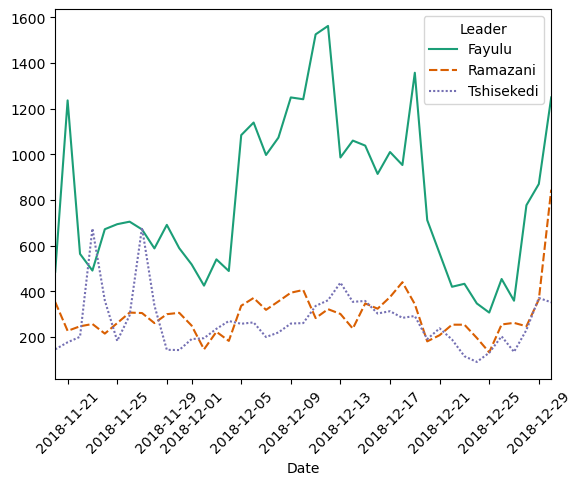

In [3]:
# Number of tweets per leader

sns.lineplot(data = df.pivot_table(values = "Quote", columns = "Leader", index = "Date", aggfunc = "count"),
             palette = 'Dark2')
#plt.title('Evolution du nombre de tweets par leader')
plt.xticks(rotation=45)
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.savefig('evolution_of_the_number_of_tweets_per_leader.pdf', bbox_inches = 'tight', pad_inches = .1);

Leader
Fayulu        33041
Ramazani      12196
Tshisekedi    10982
dtype: int64

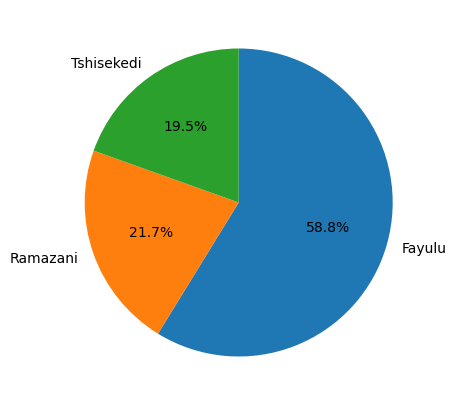

In [4]:
# Total number of tweets per leader

plt.figure(figsize = (5,5))
plt.pie(x = df['Leader'].value_counts(normalize = True, ascending = False), labels = df.groupby('Leader').size().index,
        autopct = '%2.1f%%', counterclock = False, startangle = 90)
plt.savefig('distribution_of_tweets_per_leader.pdf', bbox_inches = 'tight', pad_inches = .1);
df.groupby('Leader').size()

In [5]:
# Counting tweets per localization

location = df['Place'].value_counts()
location = location.to_frame()
location.rename(columns = {'count':'Frequency'}, inplace = True)
location.index.names = ['Place']
location.reset_index(inplace = True)
location.sample(10)

,Place,Frequency
302,"Brasília, Brasil",17
1989,Kinshasa/ R D Congo,1
569,"Nairobi, Kenya....The DRC",7
1614,"Euless, TX",1
1985,"Côtes-d'Armor, Bretagne",1
1868,"Louvain, Belgique",1
410,Rdc-Kanyabayonga,12
1701,"Brussels, BELGIUM",1
195,R.,29
330,Bukavu,16


In [6]:
# Place string normalization (lowercase, remove accents & punctuation, collapse spaces)

def place_normalization(s):
    if pd.isna(s):
        return ""
    s = str(s)
    # unicode normalize and drop accents
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("ascii")
    # lowercase, replace non-alphanum by space, collapse spaces
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s-]", " ", s)
    s = re.sub(r"[\s\-]+", " ", s).strip()
    return s

In [7]:
# Canonical map: canonical_name -> list of substrings to match (normalized)

canonical_map = {
    "DRC":            ["rdc", "dr congo", "democratic republic", "democratic republic of congo",
                       "republique democratique du con"],
    "Kinshasa":       ["kinshasa", r"\bkin\b", "kin"],
    "Goma":           ["goma", "nord kivu", "nord-kivu", "nordkivu"],
    "Bukavu":         ["bukavu"],
    "Beni":           ["beni"],
    "Bunia":          ["bunia", "unia"],
    "Butembo":        ["butembo"],
    "Lubumbashi":     ["lubumbashi"],
    "Kisangani":      ["kisangani"],
    "Mbuji-Mayi":     ["mbuji", "mbuji-mayi", "mbuji mayi"],
    "Likasi":         ["likasi"],
    "Kolwezi":        ["kolwezi"],
    "Kalemie":        ["kalemie", "alemi"],
    "Kananga":        ["kananga"],
    "Kikwit":         ["kikwit"],
    "Matadi":         ["matadi"],
    "Uvira":          ["uvira"],
    "Bumba":          ["bumba"],
    "Bandundu":       ["bandundu"],
    # international / capitals (examples)
    "France":         ["france", "paris"],
    "Belgium":        ["brussel", "bruxel", "bruxelles", "belgique", "belgi"],
    "USA":            ["united states", "usa", "tats unis", "states", "new-york", "new york", "ny"],
    "Canada":         ["canada", "montreal", "quebec", "ottawa", "ontario"],
    "Angola":         ["luanda", "angola", "ngola"],
    "Rwanda":         ["kigali", "rwanda"],
    "South Africa":   ["cape town", "cape", "johannesburg", "south africa"],
    "Morocco":        ["casablanca", "rabat", "marrakech", "maroc"],
    "Senegal":        ["dakar", "senegal"],
    "Switzerland":    ["geneva", "geneve", "suisse", "zurich", "lausanne"],
    "United Kingdom": ["london", "england", "uk"],
    "Italy":          ["rome", "roma", "italie", "itali"],
    "Germany":        ["germany", "deutschland", "frankfurt"],
    # add or refine entries as needed...
}

In [8]:
# Vectorized cleaning and mapping
warnings.filterwarnings("ignore")
location['Place'] = location['Place'].apply(place_normalization)

# Applying canonical_map with priority order (first match wins)
location['Std_Place'] = pd.NA  # column to hold standardized canonical name

for canonical, keywords in canonical_map.items():
    # build regex pattern (word-boundary friendly)
    # escape keywords to be safe but allow small word matches
    escaped = [re.escape(k) for k in keywords]
    pattern = r"(" + r"|".join(escaped) + r")"
    mask = location['Place'].str.contains(pattern, na=False)
    # assign only where not already assigned (preserve priority)
    location.loc[mask & location['Std_Place'].isna(), 'Std_Place'] = canonical
    
# fallback: if nothing matched, use a cleaned title-case original (or keep as "Unknown")
location.loc[location['Std_Place'].isna(), 'Std_Place'] = location.loc[location['Std_Place'].isna(), 'Place'].str.strip().replace('', 'Unknown').str.title()

In [9]:
# Final grouping and aggregation after handling duplicate locations

location_clean = (
    location.groupby('Std_Place', as_index=False)
       .agg(Place=('Place','first'), Frequency=('Frequency','sum'))
       .sort_values('Frequency', ascending=False)
)

# replace original variable if desired
location = location_clean
location.sample(10)

,Std_Place,Place,Frequency
377,Katanga,katanga,3
102,Boma,boma,1
460,Manufacture De L Imaginaire,manufacture de l imaginaire,8
252,Enghien,enghien,2
125,Buenos Aires Argentine,buenos aires argentine,1
276,Force Les De Batir Ensemble,force les de batir ensemble,1
619,Republique Centrafricaine,republique centrafricaine,8
201,Cur Meurtri,cur meurtri,2
311,Guangdong People S Republic Of China,guangdong people s republic of china,4
767,Winnipeg Manitoba,winnipeg manitoba,3


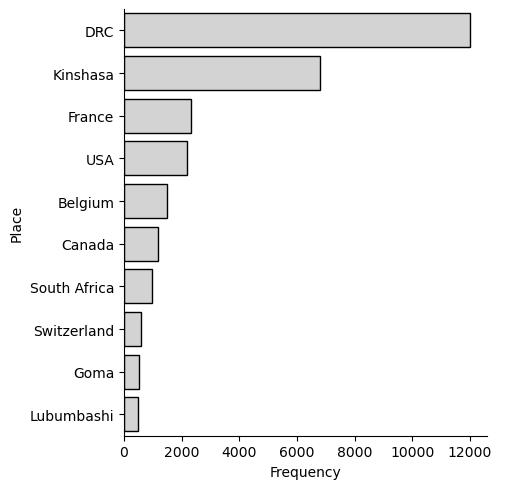

In [10]:
# Tweets per localization

sns.catplot(data=location[0:10], y="Std_Place", x="Frequency", kind="bar", color="lightgray", edgecolor="black")
plt.ylabel('Place')
plt.savefig('tweets_location.pdf', bbox_inches = 'tight', pad_inches = .1);

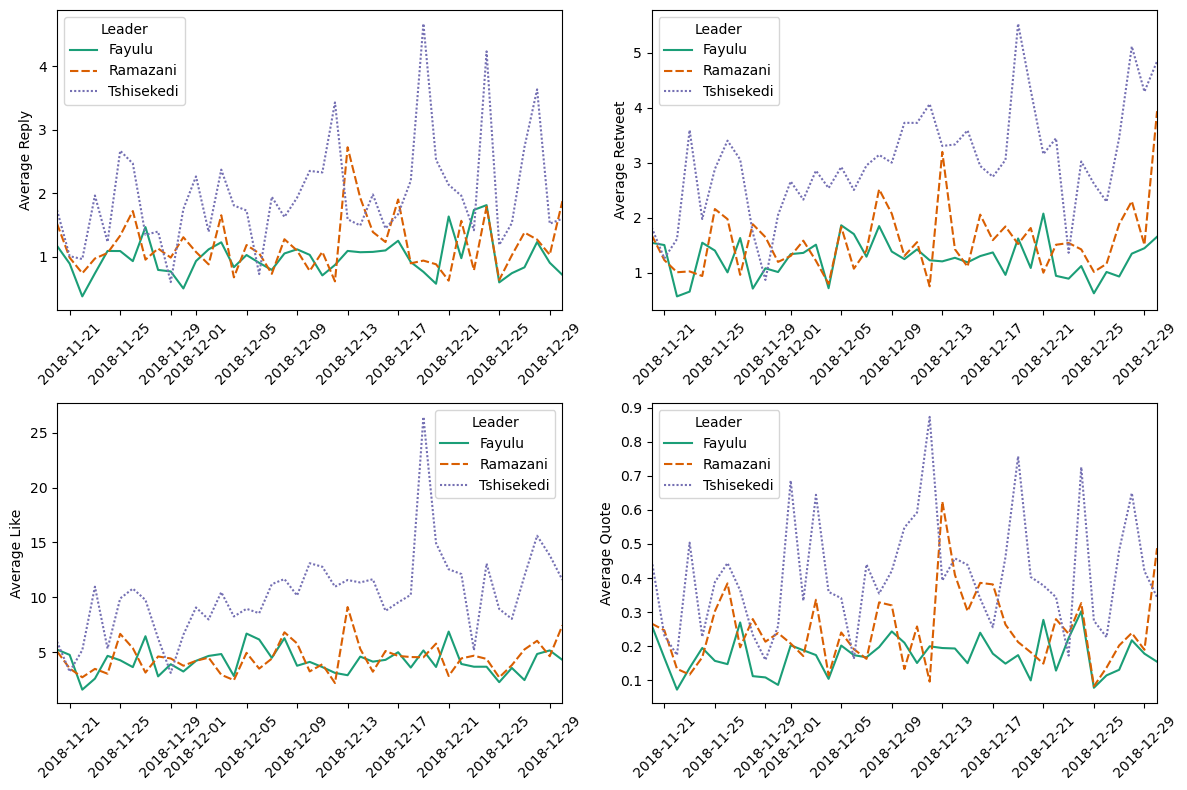

In [11]:
# Average amplification of tweets by leader over time

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(['Reply', 'Retweet', 'Like', 'Quote']):
    sns.lineplot(data=df.pivot_table(values=metric, columns='Leader', index='Date', aggfunc='mean'), 
                 ax=axes[i], palette='Dark2')
    axes[i].set_ylabel(f'Average {metric}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])

plt.tight_layout()
plt.savefig('engagement_metrics_evolution.pdf', bbox_inches='tight', pad_inches=.1);

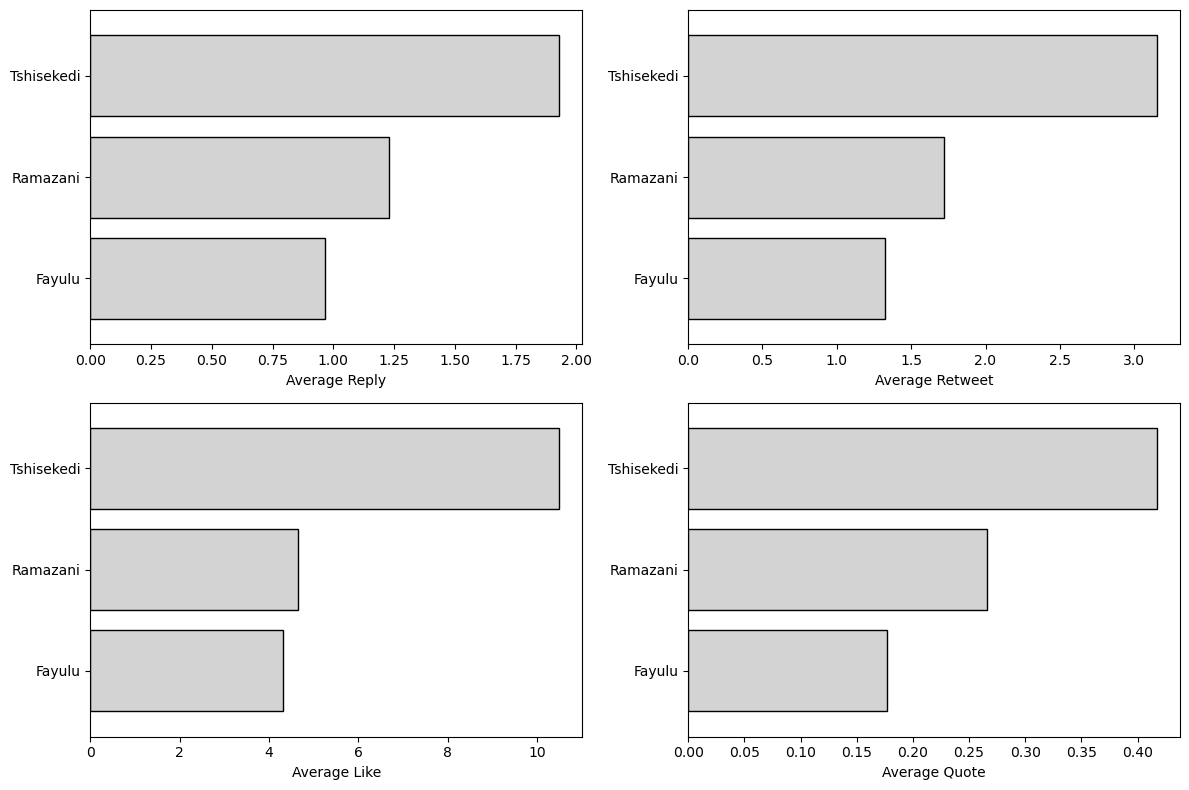

In [12]:
# Overall average engagement metrics by leader

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(['Reply', 'Retweet', 'Like', 'Quote']):
    df.groupby('Leader')[metric].mean().sort_values().plot.barh(ax=axes[i], 
                                                               color='lightgrey', 
                                                               edgecolor='black',
                                                               width=0.8)
    #axes[i].set_title(f'Average {metric} per Leader')
    axes[i].set_xlabel(f'Average {metric}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('overall_engagement_averages.pdf', bbox_inches='tight', pad_inches=.1);